# Crypt Embedding Cluster Accuracy Analysis

This notebook follows the single-model training workflow, then asks whether marker composition is cleaner in the parts of each embedding cluster where the model predicts curvature most accurately.

Workflow:

1. Load, filter, split, and train one `GINCurvature` model.
2. Cluster validation node embeddings into six coarse clusters.
3. Plot the coarse clusters with t-SNE, marker composition heatmaps, curvature boxplots, and crypt-distance categories.
4. Within each coarse cluster, keep only the 25% of nodes with the smallest absolute prediction error.
5. Re-plot t-SNE and marker composition for this accurately predicted subset.


**Setup**


In [74]:
import copy
import json
import pickle
import random
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.colors import BoundaryNorm
from sklearn.manifold import TSNE

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())


PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**


In [75]:
# Data and target settings
EXPERIMENT_GROUP = "crypt_embedding_subclustering_analysis"
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_ANALYSIS = 0
USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True

# Optional target residualization against a train-only constant+globals baseline.
SUBTRACT_CONSTANT_GLOBAL_BASELINE = True

# Filtering and preprocessing settings from train_single_model.ipynb.
FILL_MISSING_COMPLEXITY = True
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)
DAY3P5_TIMEPOINT = "day3p5"

# Split settings
VAL_FRAC = 0.2
SPLIT_SEED = None
FORCED_VAL_KEYS = {}

# Model settings
MODEL_CLASS = "GINCurvature"
NUM_LAYERS = 2
HIDDEN_DIM = 2 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True
BASELINE_HIDDEN_DIM = HIDDEN_DIM

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Clustering settings
N_COARSE_CLUSTERS = 6
ACCURATE_NODE_FRACTION = 0.25
ACCURATE_NODE_MIN_PER_CLUSTER = 1
ACCURACY_METRIC = "absolute_error"
EMBEDDING_VARIANT = "local"
RESIDUALIZE_GLOBAL_FOR_CLUSTERING = False
CLUSTERING_METHOD = "gmm"
COVARIANCE_TYPE = "full"
STANDARDIZE_EMBEDDINGS = True
PCA_DIM = 32
CLUSTER_SEED = 0
TSNE_PERPLEXITY = 30
TSNE_MAX_NODES = 15000  # Set to None to use every validation node.
TSNE_SEED = 0

# Experiment output settings
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"depth{NUM_LAYERS}_coarse{N_COARSE_CLUSTERS}_accurate{int(ACCURATE_NODE_FRACTION * 100)}_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"
TABLES_DIR = SAVE_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


**Utility Helpers**


In [76]:
def safe_filename(name):
    text = str(name).strip().replace("/", "_")
    chars = [ch if (ch.isalnum() or ch in "._-") else "_" for ch in text]
    cleaned = "".join(chars).strip("._-")
    while "__" in cleaned:
        cleaned = cleaned.replace("__", "_")
    return cleaned or "figure"


def save_mpl_figure(fig, name, *, dpi=300, close=False):
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    paths = []
    for suffix in ["pdf", "png"]:
        path = FIGURES_DIR / f"{safe_filename(name)}.{suffix}"
        fig.savefig(path, bbox_inches="tight", dpi=dpi)
        paths.append(path)
    print(f"Saved figure -> {paths[0]} and {paths[1]}")
    if close:
        plt.close(fig)
    return paths


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def rename_labels_by_value(labels, values, *, reducer=np.nanmedian):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    unique = np.array(sorted(np.unique(labels)), dtype=int)
    scores = {k: float(reducer(values[labels == k])) for k in unique}
    old_to_new = {old: new for new, old in enumerate(sorted(unique, key=lambda k: scores[k]))}
    renamed = np.asarray([old_to_new[int(k)] for k in labels], dtype=int)
    return renamed, old_to_new, scores


## Load And Filter Data


In [77]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    add_log_metadata_features,
    attach_metadata_to_graphs,
    fill_missing_metadata_for_group,
    infer_global_dim,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
    promote_metadata_to_graph_tensors,
    snapshot_graph_metadata,
    strip_graph_metadata,
)
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_metadata,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)
from src.models.gnn import GINCurvature, JKGINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term


data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)


Loaded 1423 graphs; skipped 0.
Loaded 1423 organoids.
Raw y shape: (165, 2)
Attached metadata to 1423/1423 graphs.
Selected y shape: (165,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [78]:
# Default train_single_model.ipynb behavior: remove day3p5 if present.
graphs = filter_graphs_by_metadata(
    graphs,
    key="timepoint",
    drop_values={DAY3P5_TIMEPOINT},
    missing="keep",
    inplace=False,
    print_summary=True,
)

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(
        graphs,
        blacklist,
        print_summary=True,
    )
else:
    blacklist = set()
    print("Blacklist filtering disabled.")

if FILL_MISSING_COMPLEXITY:
    graphs = fill_missing_metadata_for_group(
        graphs,
        field="complexity",
        fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
        dataset=MISSING_COMPLEXITY_GROUP["dataset"],
        timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
    )

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)

g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)

graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)

# Match train_single_model.ipynb: spherical rejected graphs are not added back by default.
# graphs = graphs + g_spherical
print(f"After filtering: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None


filter_graphs_by_metadata(key='timepoint'): kept 1134 / 1423 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    289    0.000
20250929         day4                342    342    1.000
20250929         day4p5              104    104    1.000
20250929         day4p5-more         411    411    1.000
20251201         day4p5              277    277    1.000
filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total  

## Train One Model


In [79]:
field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    force_val_keys=FORCED_VAL_KEYS,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

val_meta_lookup = snapshot_graph_metadata(g_val)
g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)


Promoted metadata fields to graph tensor attributes.
Split -> train: 565 | val: 141


In [80]:
center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

baseline_residual_transform = None
if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
    baseline_residual_transform = GlobalBaselineResidualTransform(num_workers=NUM_WORKERS)
    target_transform = ChainedTargetTransform([
        baseline_residual_transform,
        AsinhStandardizeTransform(robust=True),
    ])
    training_target_description = "target residual: true curvature - constant+globals baseline"
else:
    target_transform = AsinhStandardizeTransform(robust=True)
    training_target_description = "raw target"

print("Training target:", training_target_description)

target_transform.fit(g_train)
target_transform.transform_graphs(g_train, in_place=True)
target_transform.transform_graphs(g_val, in_place=True)

baseline_model = getattr(baseline_residual_transform, "model", None)
baseline_metrics = getattr(baseline_residual_transform, "metrics", None)
baseline_history = getattr(baseline_residual_transform, "history", None)


Training target: target residual: true curvature - constant+globals baseline
epoch 001 | train loss -0.0909 mae 0.1125 | val loss -0.1118 mae 0.0993
epoch 002 | train loss -0.1203 mae 0.1007 | val loss -0.1415 mae 0.0870
epoch 003 | train loss -0.1504 mae 0.0904 | val loss -0.1720 mae 0.0759
epoch 004 | train loss -0.1803 mae 0.0827 | val loss -0.2039 mae 0.0664
epoch 005 | train loss -0.2124 mae 0.0769 | val loss -0.2372 mae 0.0595
epoch 006 | train loss -0.2459 mae 0.0735 | val loss -0.2725 mae 0.0546
epoch 007 | train loss -0.2814 mae 0.0716 | val loss -0.3105 mae 0.0511
epoch 008 | train loss -0.3188 mae 0.0712 | val loss -0.3518 mae 0.0495
epoch 009 | train loss -0.3599 mae 0.0713 | val loss -0.3963 mae 0.0488
epoch 010 | train loss -0.4038 mae 0.0720 | val loss -0.4444 mae 0.0487
epoch 011 | train loss -0.4509 mae 0.0728 | val loss -0.4969 mae 0.0480
epoch 012 | train loss -0.5007 mae 0.0733 | val loss -0.5537 mae 0.0467
epoch 013 | train loss -0.5523 mae 0.0737 | val loss -0.614

In [81]:
n_markers = int(g_train[0].x.size(1))
global_dim = infer_global_dim(g_train)

model_cls = {"GINCurvature": GINCurvature, "JKGINCurvature": JKGINCurvature}[MODEL_CLASS]
model = model_cls(
    n_markers=n_markers,
    global_dim=global_dim,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
)

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

model, metrics, history = train(model, g_train, g_val, cfg)


epoch 001 | train loss 0.5298 mae 0.7751 | val loss 0.5437 mae 0.8029
epoch 002 | train loss 0.4870 mae 0.7490 | val loss 0.5292 mae 0.7976
epoch 003 | train loss 0.4736 mae 0.7415 | val loss 0.5046 mae 0.7817
epoch 004 | train loss 0.4619 mae 0.7326 | val loss 0.4924 mae 0.7767
epoch 005 | train loss 0.4557 mae 0.7309 | val loss 0.4788 mae 0.7676
epoch 006 | train loss 0.4486 mae 0.7269 | val loss 0.4700 mae 0.7609
epoch 007 | train loss 0.4429 mae 0.7234 | val loss 0.4622 mae 0.7576
epoch 008 | train loss 0.4380 mae 0.7214 | val loss 0.4510 mae 0.7480
epoch 009 | train loss 0.4353 mae 0.7191 | val loss 0.4523 mae 0.7489
epoch 010 | train loss 0.4323 mae 0.7188 | val loss 0.4389 mae 0.7378
epoch 011 | train loss 0.4305 mae 0.7163 | val loss 0.4388 mae 0.7402
epoch 012 | train loss 0.4246 mae 0.7147 | val loss 0.4339 mae 0.7369
epoch 013 | train loss 0.4215 mae 0.7122 | val loss 0.4260 mae 0.7291
epoch 014 | train loss 0.4195 mae 0.7111 | val loss 0.4361 mae 0.7401
epoch 015 | train lo

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/training_loss.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/training_loss.png


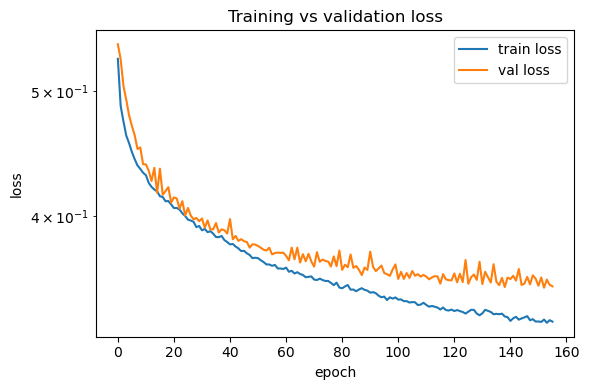

In [82]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.get("train_loss", []), label="train loss")
ax.plot(history.get("val_loss", []), label="val loss")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_title("Training vs validation loss")
ax.legend()
fig.tight_layout()
save_mpl_figure(fig, "training_loss")
plt.show()


## Clustering And Plot Helpers


In [83]:
from src.analysis.motif_clustering import run_embedding_clustering
from src.analysis.marker_stats import append_none_marker_column
from src.analysis.cluster_analysis import (
    build_binned_cluster_fraction_table,
    cluster_marker_distribution,
    cluster_marker_means,
    cluster_order_from_values,
)
from src.plotting.cluster_plots import (
    plot_cluster_boxplots,
    plot_cluster_marker_heatmap,
    plot_cluster_metadata_boxplots,
)


In [84]:
def sample_for_tsne(Z, labels, *, max_nodes=TSNE_MAX_NODES, seed=TSNE_SEED):
    Z = np.asarray(Z)
    labels = np.asarray(labels)
    n = Z.shape[0]
    if max_nodes is None or n <= max_nodes:
        idx = np.arange(n)
    else:
        rng = np.random.default_rng(seed)
        idx = np.sort(rng.choice(n, size=int(max_nodes), replace=False))
    return Z[idx], labels[idx], idx


def plot_tsne_clusters(Z, labels, title, filename, *, max_nodes=TSNE_MAX_NODES):
    Z_plot, labels_plot, idx = sample_for_tsne(Z, labels, max_nodes=max_nodes)
    perplexity = min(TSNE_PERPLEXITY, max(5, (Z_plot.shape[0] - 1) // 3))
    Z2 = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=TSNE_SEED,
        init="pca",
        learning_rate="auto",
    ).fit_transform(Z_plot)

    K = int(np.max(labels_plot)) + 1
    cmap = plt.get_cmap("tab10", K)
    bounds = np.arange(K + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    sc = ax.scatter(
        Z2[:, 0],
        Z2[:, 1],
        c=labels_plot,
        cmap=cmap,
        norm=norm,
        s=8,
        linewidths=0,
    )
    cbar = fig.colorbar(sc, ax=ax, ticks=np.arange(K))
    cbar.set_label("cluster")
    cbar.set_ticklabels([f"C{k}" for k in range(K)])
    suffix = "" if len(idx) == len(labels) else f" (sampled {len(idx):,}/{len(labels):,} nodes)"
    ax.set_title(title + suffix)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax, idx


def plot_marker_composition_suite(X_markers, labels, marker_names, title_prefix, filename_prefix):
    X_ext, marker_names_ext = append_none_marker_column(X_markers, marker_names)
    marker_means = cluster_marker_means(X_ext, labels)
    marker_distribution = cluster_marker_distribution(X_ext, labels)

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=False)
    plot_cluster_marker_heatmap(
        marker_means,
        marker_names_ext,
        title=f"{title_prefix} | marker means",
        ax=axes[0],
        show_colorbar=False,
    )
    plot_cluster_marker_heatmap(
        marker_distribution,
        marker_names_ext,
        title=f"{title_prefix} | marker distribution",
        ax=axes[1],
        show_colorbar=True,
        colorbar_label="fraction of marker-positive nodes in cluster",
    )
    fig.tight_layout()
    save_mpl_figure(fig, f"{filename_prefix}_marker_composition")
    plt.show()
    return {
        "X_ext": X_ext,
        "marker_names_ext": marker_names_ext,
        "marker_means": marker_means,
        "marker_distribution": marker_distribution,
    }


def plot_true_pred_curvature_boxplots(y_true, y_pred, labels, title, filename):
    cluster_order = cluster_order_from_values(labels, y_pred, reducer=np.nanmean)
    fig, ax = plot_cluster_boxplots(
        [y_true, y_pred],
        labels,
        data_labels=["true", "predicted"],
        colors=["lightblue", "lightgreen"],
        ylabel="curvature",
        title=title,
        cluster_order=cluster_order,
        show_outliers=False,
        figsize=(11, 4.5),
    )
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax, cluster_order


def dcrypt_to_bin(dmin, has_crypt):
    if (not has_crypt) or (not np.isfinite(dmin)):
        return "No crypt"
    if dmin < 0.8:
        return "< 0.8"
    if dmin <= 1.2:
        return "0.8 - 1.2"
    return "> 1.2"


DCRYPT_BIN_ORDER = ["No crypt", "< 0.8", "0.8 - 1.2", "> 1.2"]
DCRYPT_BIN_COLORS = {
    "No crypt": "lightgray",
    "< 0.8": "tab:blue",
    "0.8 - 1.2": "tab:orange",
    "> 1.2": "tab:green",
}


def plot_crypt_distance_categories(labels, dcrypt_min, title, filename):
    dcrypt_min = np.asarray(dcrypt_min, dtype=float)
    has_crypt = np.isfinite(dcrypt_min)
    plot_table, cluster_order, df_bins = build_binned_cluster_fraction_table(
        labels=labels,
        values=dcrypt_min,
        valid_mask=has_crypt,
        bin_func=dcrypt_to_bin,
        bin_order=DCRYPT_BIN_ORDER,
        cluster_order_by="median_valid_value",
        include_all=True,
    )

    fig, ax = plt.subplots(figsize=(11, 5))
    bottom = np.zeros(len(plot_table), dtype=float)
    for bin_name in DCRYPT_BIN_ORDER:
        vals = plot_table[bin_name].values
        ax.bar(
            np.arange(len(plot_table)),
            vals,
            bottom=bottom,
            label=bin_name,
            color=DCRYPT_BIN_COLORS[bin_name],
        )
        bottom += vals

    xticklabels = ["All"] + [f"C{k}" for k in cluster_order]
    ax.set_xticks(np.arange(len(plot_table)))
    ax.set_xticklabels(xticklabels, rotation=45)
    ax.set_xlabel("group")
    ax.set_ylabel("fraction of nodes")
    ax.set_title(title)
    ax.legend(title="min distance to crypt")
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return plot_table, cluster_order, df_bins


def make_cluster_plot_suite(pack, *, title_prefix, filename_prefix):
    plot_tsne_clusters(
        pack["embeddings_used"],
        pack["labels"],
        f"{title_prefix} | embedding clusters",
        f"{filename_prefix}_tsne_clusters",
    )
    marker_pack = plot_marker_composition_suite(
        pack["x_markers"],
        pack["labels"],
        marker_names,
        title_prefix,
        filename_prefix,
    )
    fig_box, ax_box, cluster_order = plot_true_pred_curvature_boxplots(
        pack["y_true"],
        pack["y_pred"],
        pack["labels"],
        f"{title_prefix} | true vs predicted curvature",
        f"{filename_prefix}_true_vs_predicted_curvature_boxplots",
    )
    dcrypt_table, dcrypt_order, df_dcrypt_bins = plot_crypt_distance_categories(
        pack["labels"],
        pack["dcrypt_min"],
        f"{title_prefix} | crypt-distance categories by cluster",
        f"{filename_prefix}_crypt_distance_categories",
    )
    pack.update(marker_pack)
    pack.update({
        "cluster_order": cluster_order,
        "dcrypt_table": dcrypt_table,
        "dcrypt_cluster_order": dcrypt_order,
        "df_dcrypt_bins": df_dcrypt_bins,
    })
    return pack


def best_predicted_mask_by_cluster(labels, y_true, y_pred, *, fraction=0.25, min_per_cluster=1):
    labels = np.asarray(labels, dtype=int)
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if labels.shape[0] != y_true.shape[0] or labels.shape[0] != y_pred.shape[0]:
        raise ValueError("labels, y_true, and y_pred must have the same length.")
    if not (0 < fraction <= 1):
        raise ValueError("fraction must be in (0, 1].")

    abs_error = np.abs(y_pred - y_true)
    keep = np.zeros(labels.shape[0], dtype=bool)
    rows = []
    for cluster in np.sort(np.unique(labels)):
        idx = np.where(labels == cluster)[0]
        finite = idx[np.isfinite(abs_error[idx])]
        n_available = int(finite.size)
        n_keep = min(n_available, max(int(min_per_cluster), int(np.ceil(fraction * n_available))))
        if n_keep > 0:
            order = finite[np.argsort(abs_error[finite], kind="mergesort")]
            chosen = order[:n_keep]
            keep[chosen] = True
            threshold = float(abs_error[chosen[-1]])
        else:
            threshold = np.nan
        rows.append({
            "cluster": int(cluster),
            "n_available": n_available,
            "n_kept": int(n_keep),
            "kept_fraction": float(n_keep / n_available) if n_available > 0 else np.nan,
            "absolute_error_threshold": threshold,
            "median_abs_error_all": float(np.nanmedian(abs_error[idx])) if idx.size else np.nan,
            "median_abs_error_kept": float(np.nanmedian(abs_error[keep & (labels == cluster)])) if n_keep > 0 else np.nan,
        })
    return keep, pd.DataFrame(rows), abs_error


## Coarse Embedding Clustering


In [85]:
extraction, clustering_result, summary = run_embedding_clustering(
    graphs=g_val,
    model=model,
    batch_size=BATCH_SIZE,
    center_only=False,
    embedding_variant=EMBEDDING_VARIANT,
    residualize_global=RESIDUALIZE_GLOBAL_FOR_CLUSTERING,
    clustering=CLUSTERING_METHOD,
    n_clusters=N_COARSE_CLUSTERS,
    k_values=range(2, 11),
    covariance_type=COVARIANCE_TYPE,
    standardize=STANDARDIZE_EMBEDDINGS,
    pca_dim=PCA_DIM,
    seed=CLUSTER_SEED,
    marker_names=marker_names,
)

Y_true, Y_pred, log_var = target_transform.inverse_distribution(
    extraction.y_true,
    extraction.y_pred,
    log_var=extraction.log_var,
    graphs=g_val,
)
Y_true = select_target_column(Y_true, TARGET_INDEX_FOR_ANALYSIS)
Y_pred = select_target_column(Y_pred, TARGET_INDEX_FOR_ANALYSIS)
log_var = None if log_var is None else select_target_column(log_var, TARGET_INDEX_FOR_ANALYSIS)

labels_raw = clustering_result.labels
labels, coarse_old_to_new, coarse_scores = rename_labels_by_value(
    labels_raw,
    Y_true,
    reducer=np.nanmedian,
)
clustering_result.labels = labels

summary_df = pd.DataFrame(summary)
print("Coarse label remap:", coarse_old_to_new)
print("Coarse cluster median true curvature before remap:", coarse_scores)
print("Coarse cluster sizes:")
display(pd.Series(labels).value_counts().sort_index().rename("n_nodes").to_frame())


Coarse label remap: {np.int64(4): 0, np.int64(5): 1, np.int64(3): 2, np.int64(0): 3, np.int64(2): 4, np.int64(1): 5}
Coarse cluster median true curvature before remap: {np.int64(0): 0.02471469363700599, np.int64(1): 0.061365545854303295, np.int64(2): 0.0450397896839734, np.int64(3): 0.02333237908950715, np.int64(4): 0.021254584951041343, np.int64(5): 0.02192813044442203}
Coarse cluster sizes:


,n_nodes
0,6826
1,11871
2,13428
3,10072
4,10868
5,13639


In [86]:
get_min_node_val = lambda x, n_nodes: (
    lambda a: (
        np.full(n_nodes, np.nan)
        if a.size == 0 else
        a.astype(float)
        if a.ndim == 1 else
        np.min(a, axis=0).astype(float)
        if a.shape[1] >= n_nodes else
        np.min(a, axis=1).astype(float)
    )
)(np.asarray(x))

fig_tmp, ax_tmp, df_dcrypt = plot_cluster_metadata_boxplots(
    g_val,
    labels,
    fields="d_crypts_graph",
    meta_lookup=val_meta_lookup,
    transform=get_min_node_val,
    return_dataframe=True,
)
plt.close(fig_tmp)

dcrypt_min = df_dcrypt["value"].to_numpy(dtype=float)
assert len(dcrypt_min) == len(labels)


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_tsne_clusters.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_tsne_clusters.png


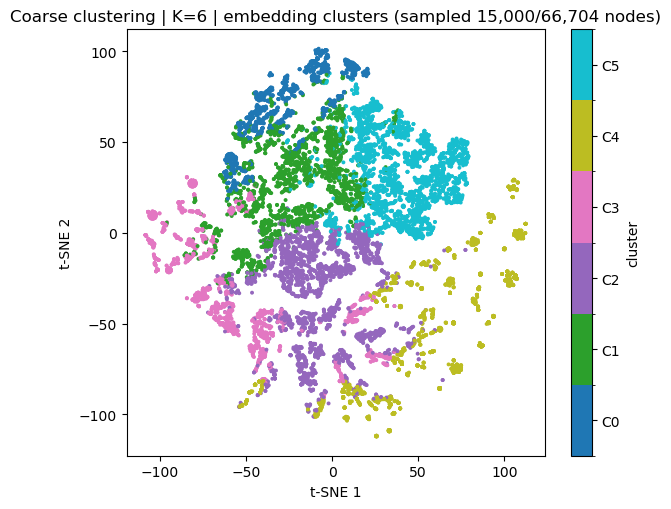

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_marker_composition.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_marker_composition.png


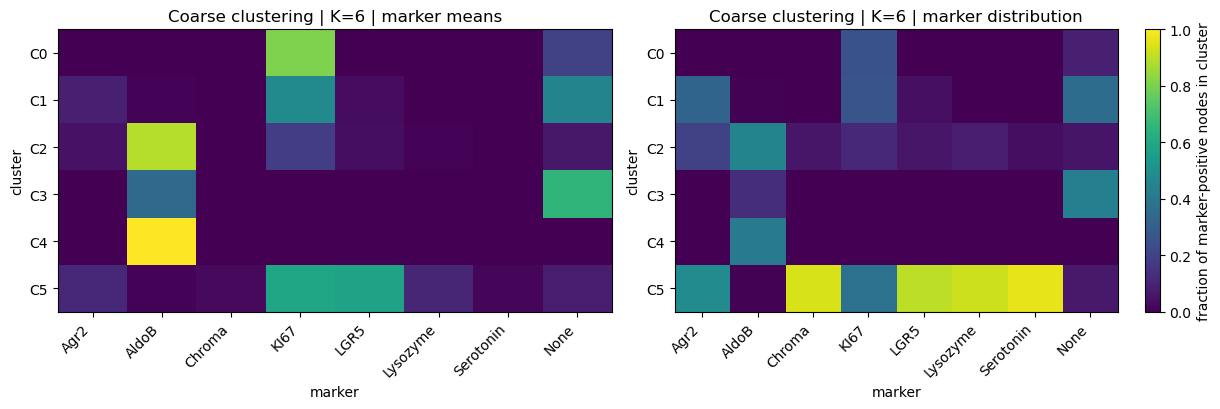

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_true_vs_predicted_curvature_boxplots.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_true_vs_predicted_curvature_boxplots.png


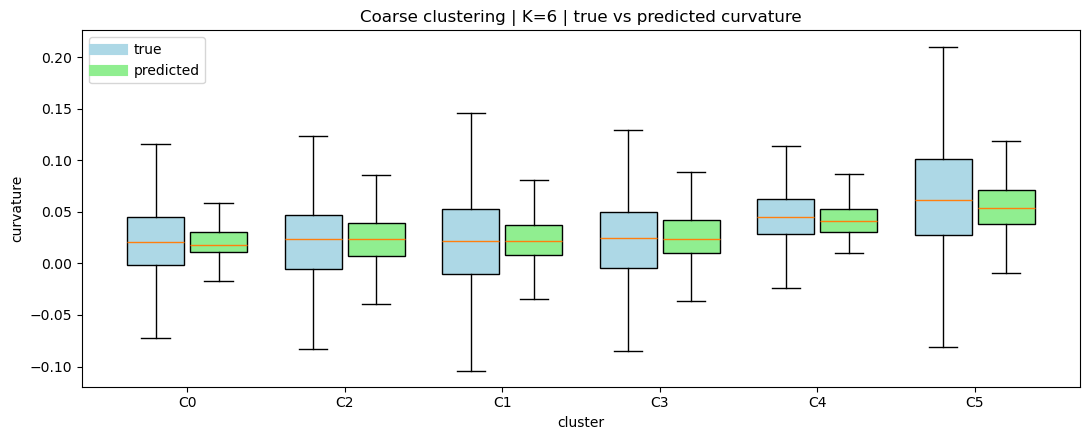

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_crypt_distance_categories.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_crypt_distance_categories.png


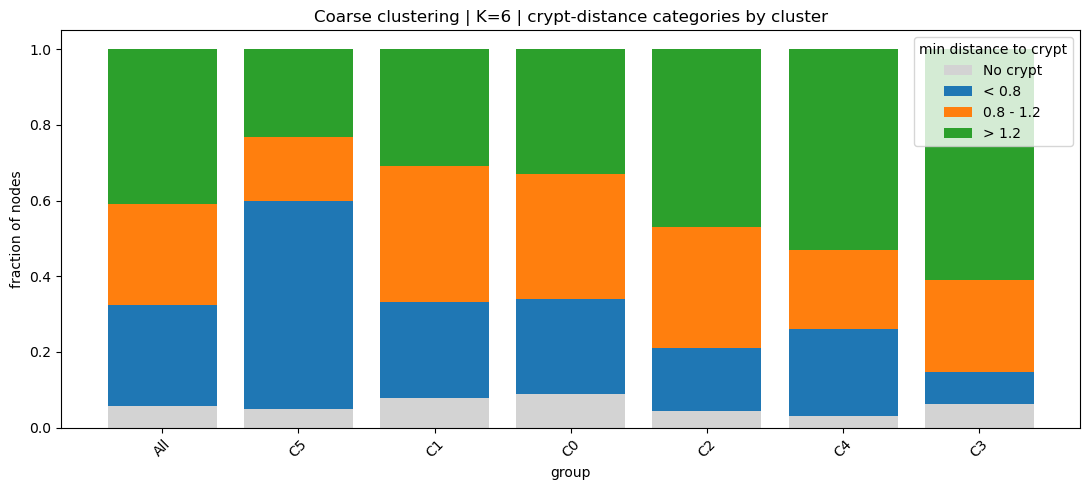

In [87]:
coarse_pack = {
    "labels": labels,
    "embeddings_used": clustering_result.embeddings_used,
    "x_markers": extraction.x_markers,
    "y_true": Y_true,
    "y_pred": Y_pred,
    "log_var": log_var,
    "dcrypt_min": dcrypt_min,
}
coarse_pack = make_cluster_plot_suite(
    coarse_pack,
    title_prefix=f"Coarse clustering | K={N_COARSE_CLUSTERS}",
    filename_prefix="coarse",
)


## Most Accurately Predicted Nodes

For each coarse cluster, keep only the nodes with the smallest absolute prediction error. This preserves every cluster while focusing on the subset where the learned embedding-to-curvature relation is least ambiguous.


Keeping 16677/66704 nodes (25.0%) across clusters.


,cluster,n_available,n_kept,kept_fraction,absolute_error_threshold,median_abs_error_all,median_abs_error_kept
0,0,6826,1707,0.250073,0.009835,0.020863,0.004742
1,1,11871,2968,0.250021,0.011516,0.025294,0.005698
2,2,13428,3357,0.250000,0.010588,0.022454,0.005039
3,3,10072,2518,0.250000,0.011068,0.022706,0.005767
4,4,10868,2717,0.250000,0.007993,0.016931,0.003957
5,5,13639,3410,0.250018,0.012574,0.028265,0.006010


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_accurate_nodes_tsne_clusters.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_accurate_nodes_tsne_clusters.png


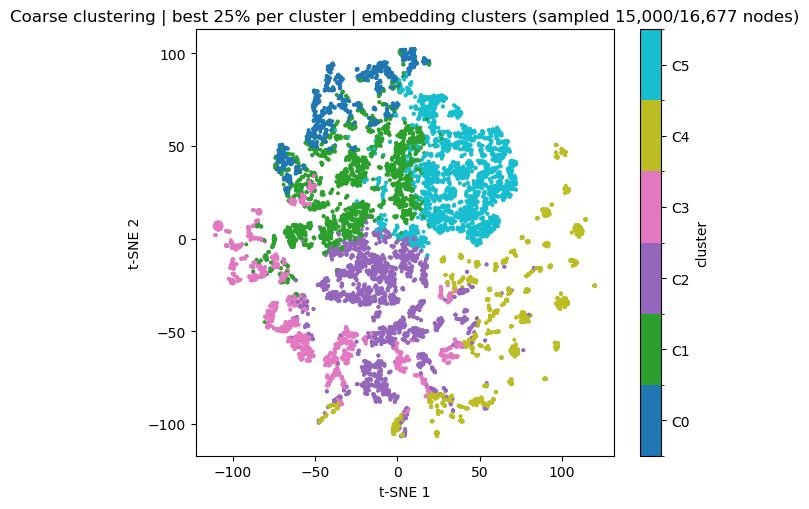

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_accurate_nodes_marker_composition.pdf and /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850/figures/coarse_accurate_nodes_marker_composition.png


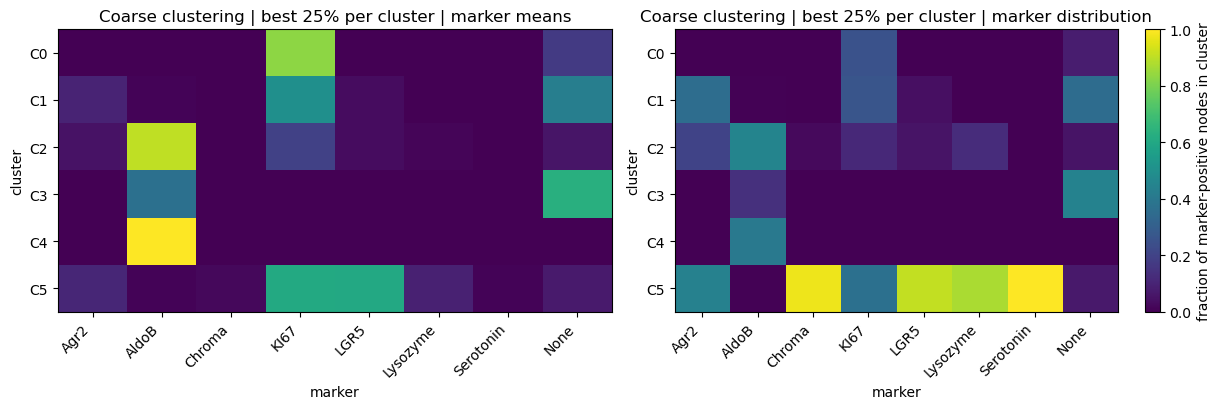

In [88]:
accurate_mask, accurate_node_summary_df, absolute_error = best_predicted_mask_by_cluster(
    labels,
    Y_true,
    Y_pred,
    fraction=ACCURATE_NODE_FRACTION,
    min_per_cluster=ACCURATE_NODE_MIN_PER_CLUSTER,
)

print(
    f"Keeping {int(accurate_mask.sum())}/{len(accurate_mask)} nodes "
    f"({accurate_mask.mean():.1%}) across clusters."
)
display(accurate_node_summary_df)

accurate_pack = {
    "labels": labels[accurate_mask],
    "embeddings_used": clustering_result.embeddings_used[accurate_mask],
    "x_markers": extraction.x_markers[accurate_mask],
    "y_true": Y_true[accurate_mask],
    "y_pred": Y_pred[accurate_mask],
    "log_var": None if log_var is None else log_var[accurate_mask],
    "dcrypt_min": dcrypt_min[accurate_mask],
    "absolute_error": absolute_error[accurate_mask],
}

plot_tsne_clusters(
    accurate_pack["embeddings_used"],
    accurate_pack["labels"],
    f"Coarse clustering | best {ACCURATE_NODE_FRACTION:.0%} per cluster | embedding clusters",
    "coarse_accurate_nodes_tsne_clusters",
)
accurate_marker_pack = plot_marker_composition_suite(
    accurate_pack["x_markers"],
    accurate_pack["labels"],
    marker_names,
    f"Coarse clustering | best {ACCURATE_NODE_FRACTION:.0%} per cluster",
    "coarse_accurate_nodes",
)
accurate_pack.update(accurate_marker_pack)


## Save Results


In [89]:
coarse_summary_df = pd.DataFrame({
    "cluster": np.sort(np.unique(labels)),
    "n_nodes": [int(np.sum(labels == k)) for k in np.sort(np.unique(labels))],
    "median_true_curvature": [float(np.nanmedian(Y_true[labels == k])) for k in np.sort(np.unique(labels))],
    "mean_true_curvature": [float(np.nanmean(Y_true[labels == k])) for k in np.sort(np.unique(labels))],
    "mean_pred_curvature": [float(np.nanmean(Y_pred[labels == k])) for k in np.sort(np.unique(labels))],
    "median_abs_error": [float(np.nanmedian(absolute_error[labels == k])) for k in np.sort(np.unique(labels))],
})

coarse_summary_df.to_csv(TABLES_DIR / "coarse_cluster_summary.csv", index=False)
accurate_node_summary_df.to_csv(TABLES_DIR / "accurate_node_summary_by_cluster.csv", index=False)
coarse_pack["dcrypt_table"].to_csv(TABLES_DIR / "coarse_crypt_distance_category_fractions.csv")

joint_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_analysis": TARGET_INDEX_FOR_ANALYSIS,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
    "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    "num_layers": NUM_LAYERS,
    "model": {
        "class": MODEL_CLASS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "filtering": {
        "day3p5_timepoint_removed": DAY3P5_TIMEPOINT,
        "blacklist_n_keys": len(blacklist),
        "fill_missing_complexity": FILL_MISSING_COMPLEXITY,
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
        "spherical_rescue_enabled": False,
    },
    "clustering": {
        "n_coarse_clusters": N_COARSE_CLUSTERS,
        "embedding_variant": EMBEDDING_VARIANT,
        "residualize_global": RESIDUALIZE_GLOBAL_FOR_CLUSTERING,
        "method": CLUSTERING_METHOD,
        "covariance_type": COVARIANCE_TYPE,
        "standardize": STANDARDIZE_EMBEDDINGS,
        "pca_dim": PCA_DIM,
        "seed": CLUSTER_SEED,
    },
    "accurate_node_filter": {
        "metric": ACCURACY_METRIC,
        "fraction_per_cluster": ACCURATE_NODE_FRACTION,
        "min_per_cluster": ACCURATE_NODE_MIN_PER_CLUSTER,
    },
    "n_graphs_after_filtering": len(graphs),
    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),
    "marker_names": list(marker_names),
    "figures_dir": str(FIGURES_DIR),
    "tables_dir": str(TABLES_DIR),
}

results_by_experiment = {
    "metrics": metrics,
    "history": history,
    "split_info": split_info,
    "baseline_metrics": baseline_metrics,
    "baseline_history": baseline_history,
    "outlier_info": outlier_info,
    "coarse_summary_df": coarse_summary_df,
    "accurate_node_summary_df": accurate_node_summary_df,
    "coarse_labels": labels,
    "accurate_mask": accurate_mask,
    "absolute_error": absolute_error,
    "coarse_pack": coarse_pack,
    "accurate_pack": accurate_pack,
}

SAVE_DIR.mkdir(parents=True, exist_ok=True)
with open(SAVE_DIR / "config.json", "w") as f:
    json.dump(joint_config, f, indent=2)
with open(SAVE_DIR / "results.pkl", "wb") as f:
    pickle.dump(results_by_experiment, f)
with open(SAVE_DIR / "meta.json", "w") as f:
    json.dump(
        {
            "timestamp": datetime.now().isoformat(),
            "notes": "Single-model coarse embedding clustering with per-cluster accurate-node marker composition analysis.",
        },
        f,
        indent=2,
    )

print(f"Saved cluster accuracy analysis experiment -> {SAVE_DIR}")
display(coarse_summary_df)
display(accurate_node_summary_df)


Saved cluster accuracy analysis experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/crypt_embedding_subclustering_analysis/depth2_coarse6_accurate25_20260603_153850


,cluster,n_nodes,median_true_curvature,mean_true_curvature,mean_pred_curvature,median_abs_error
0,0,6826,0.021255,0.018352,0.021936,0.020863
1,1,11871,0.021928,0.016235,0.022514,0.025294
2,2,13428,0.023332,0.012609,0.022220,0.022454
3,3,10072,0.024715,0.016730,0.024792,0.022706
4,4,10868,0.045040,0.043314,0.043300,0.016931
5,5,13639,0.061366,0.066576,0.056215,0.028265


,cluster,n_available,n_kept,kept_fraction,absolute_error_threshold,median_abs_error_all,median_abs_error_kept
0,0,6826,1707,0.250073,0.009835,0.020863,0.004742
1,1,11871,2968,0.250021,0.011516,0.025294,0.005698
2,2,13428,3357,0.250000,0.010588,0.022454,0.005039
3,3,10072,2518,0.250000,0.011068,0.022706,0.005767
4,4,10868,2717,0.250000,0.007993,0.016931,0.003957
5,5,13639,3410,0.250018,0.012574,0.028265,0.006010
